In [27]:
import pandas as pd 
clean_df=pd.read_csv("../data/processed/starlink_clean.csv")
clean_df["Epoch"] = pd.to_datetime(clean_df["Epoch"])


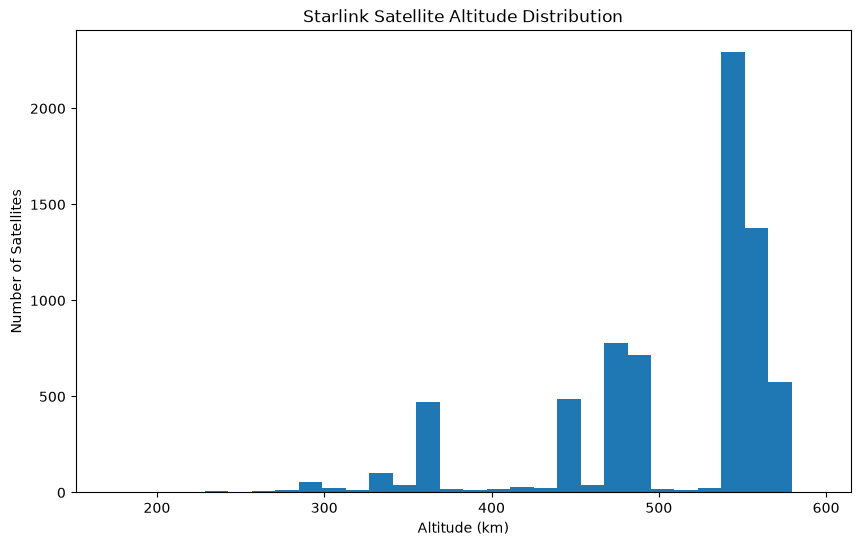

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(clean_df["Altitude_km"],bins=30)
plt.xlabel("Altitude (km)")
plt.ylabel("Number of Satellites")
plt.title("Starlink Satellite Altitude Distribution")

plt.show()

In [29]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7153 entries, 0 to 7152
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype              
---  ------                      --------------  -----              
 0   Satellite_Name              7153 non-null   str                
 1   Epoch                       7153 non-null   datetime64[us, UTC]
 2   Latitude                    7153 non-null   float64            
 3   Longitude                   7153 non-null   float64            
 4   Altitude_km                 7153 non-null   float64            
 5   Inclination_deg             7153 non-null   float64            
 6   Eccentricity                7153 non-null   float64            
 7   Mean_Motion_orbits_per_day  7153 non-null   float64            
 8   Orbit_Group                 7153 non-null   str                
dtypes: datetime64[us, UTC](1), float64(6), str(2)
memory usage: 706.7 KB


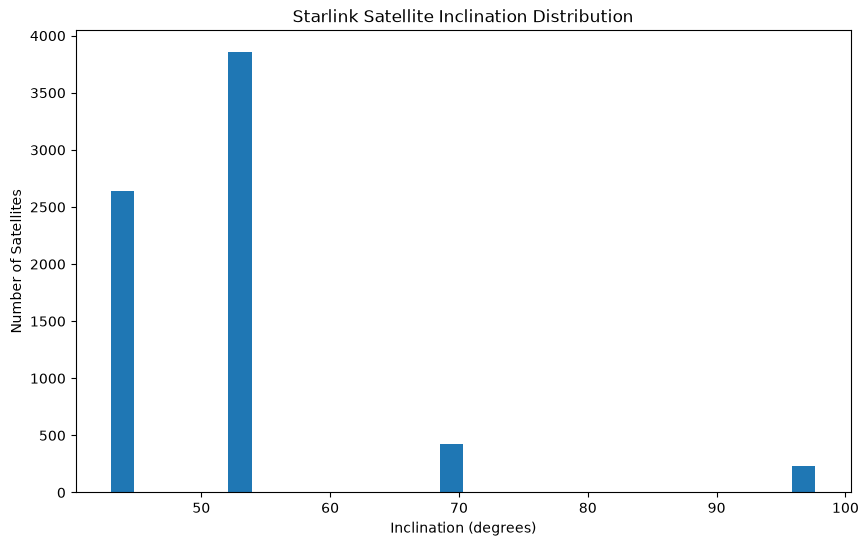

In [30]:
plt.figure(figsize=(10, 6))

plt.hist(clean_df["Inclination_deg"], bins=30)

plt.xlabel("Inclination (degrees)")
plt.ylabel("Number of Satellites")
plt.title("Starlink Satellite Inclination Distribution")

plt.show()

In [31]:
clean_df["Inclination_deg"].round(1).value_counts().sort_index()

Inclination_deg
43.0    2643
53.0     120
53.1     916
53.2    2817
70.0     427
97.6       4
97.7     226
Name: count, dtype: int64

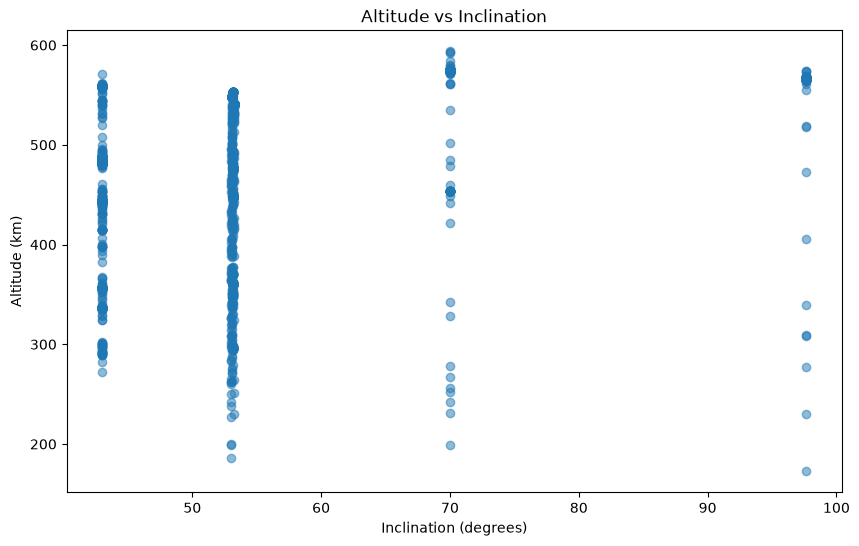

In [32]:
plt.figure(figsize=(10, 6))

plt.scatter(
    clean_df["Inclination_deg"],
    clean_df["Altitude_km"],
    alpha=0.5
)

plt.xlabel("Inclination (degrees)")
plt.ylabel("Altitude (km)")
plt.title("Altitude vs Inclination")

plt.show()

In [33]:
def classify_orbit(inclination):
    if inclination < 60:
        return "Low Inclination"
    elif inclination < 85:
        return "Medium Inclination"
    else:
        return "High Inclination"

In [34]:
clean_df["Orbit_Group"] = clean_df["Inclination_deg"].apply(classify_orbit)

In [35]:
clean_df["Orbit_Group"].value_counts()

Orbit_Group
Low Inclination       6496
Medium Inclination     427
High Inclination       230
Name: count, dtype: int64

In [36]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7153 entries, 0 to 7152
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype              
---  ------                      --------------  -----              
 0   Satellite_Name              7153 non-null   str                
 1   Epoch                       7153 non-null   datetime64[us, UTC]
 2   Latitude                    7153 non-null   float64            
 3   Longitude                   7153 non-null   float64            
 4   Altitude_km                 7153 non-null   float64            
 5   Inclination_deg             7153 non-null   float64            
 6   Eccentricity                7153 non-null   float64            
 7   Mean_Motion_orbits_per_day  7153 non-null   float64            
 8   Orbit_Group                 7153 non-null   str                
dtypes: datetime64[us, UTC](1), float64(6), str(2)
memory usage: 706.7 KB


In [37]:
clean_df.groupby("Orbit_Group")["Altitude_km"].mean()

Orbit_Group
High Inclination      557.149531
Low Inclination       500.457792
Medium Inclination    559.953043
Name: Altitude_km, dtype: float64

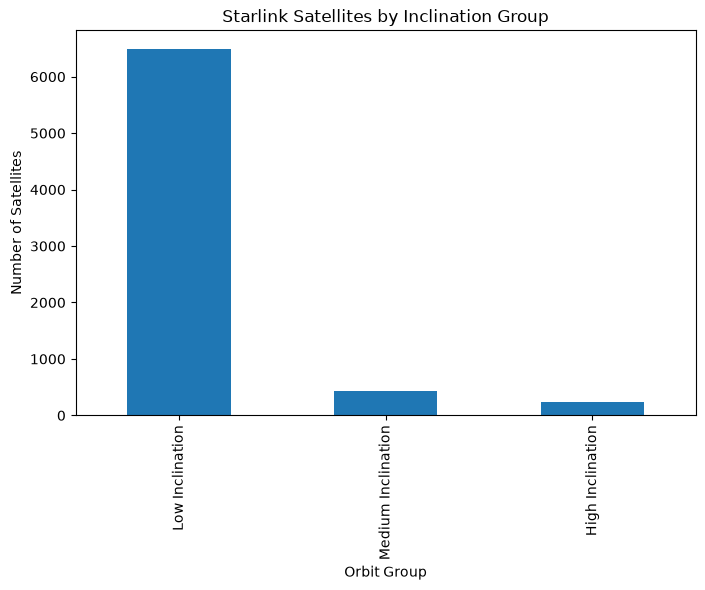

In [38]:
clean_df["Orbit_Group"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Orbit Group")
plt.ylabel("Number of Satellites")
plt.title("Starlink Satellites by Inclination Group")

plt.show()

In [39]:
clean_df.to_csv(
    "../data/processed/starlink_clean.csv",
    index=False
)

In [40]:

clean_df.head()

,Satellite_Name,Epoch,Latitude,Longitude,Altitude_km,Inclination_deg,Eccentricity,Mean_Motion_orbits_per_day,Orbit_Group
0,STARLINK-1008,2025-04-11 02:35:22.740570+00:00,0.000037,1.215090,548.002767,53.0549,0.000197,15.063938,Low Inclination
1,STARLINK-1010,2025-04-10 17:12:46.000519+00:00,-0.000024,144.010223,548.029701,53.0530,0.000154,15.064026,Low Inclination
2,STARLINK-1011,2025-04-11 10:41:00.835602+00:00,0.000034,-102.033646,547.703083,53.0531,0.000125,15.064199,Low Inclination
3,STARLINK-1012,2025-04-10 18:05:49.560577+00:00,0.000064,130.540037,547.868479,53.0539,0.000138,15.063918,Low Inclination
4,STARLINK-1013,2025-04-11 08:36:18.130737+00:00,-0.000062,-90.384818,547.776590,53.0541,0.000089,15.063825,Low Inclination


In [41]:
clean_df.groupby("Orbit_Group")["Eccentricity"].mean()

Orbit_Group
High Inclination      0.000208
Low Inclination       0.000152
Medium Inclination    0.000305
Name: Eccentricity, dtype: float64

In [42]:
lowest_altitude = clean_df.sort_values(
    "Altitude_km"
).head(10)
print(lowest_altitude)

     Satellite_Name                            Epoch   Latitude   Longitude  \
5479  STARLINK-4381 2025-04-11 11:25:16.279968+00:00  48.888288  -12.531482   
834   STARLINK-1533 2025-04-11 11:15:00.198700+00:00  34.372077 -119.627256   
5915  STARLINK-5047 2025-04-11 06:38:53.479950+00:00  55.906843   16.783836   
15    STARLINK-1035 2025-04-11 06:58:17.046906+00:00  35.534261  -64.373080   
741   STARLINK-1346 2025-04-11 05:05:48.896729+00:00  52.605434  -92.348044   
778   STARLINK-1418 2025-04-11 08:02:42.277069+00:00  53.047747  168.551298   
5539  STARLINK-4441 2025-04-11 10:22:58.103607+00:00  38.265274 -133.138348   
5694  STARLINK-4604 2025-04-11 07:55:17.654022+00:00  47.563360   -0.555996   
2422  STARLINK-3101 2025-04-11 09:05:26.178986+00:00  60.942569 -178.002708   
890   STARLINK-1619 2025-04-11 03:17:39.253632+00:00  49.765130  158.735489   

      Altitude_km  Inclination_deg  Eccentricity  Mean_Motion_orbits_per_day  \
5479   172.457616          97.6411      0.001268  

In [43]:
highest_altitude = clean_df.sort_values(
    "Altitude_km",ascending=False
).head(10)
print(highest_altitude)

      Satellite_Name                            Epoch   Latitude   Longitude  \
6139   STARLINK-5300 2025-04-10 22:00:01.999573+00:00 -62.948110  -40.722616   
3997  STARLINK-32551 2025-04-11 06:00:02.000153+00:00 -60.380344 -147.587514   
6289   STARLINK-5463 2025-04-11 14:00:01.999878+00:00 -59.131216   88.941170   
6430   STARLINK-5611 2025-04-11 12:00:02.000153+00:00 -36.670541  157.881102   
6647   STARLINK-5835 2025-04-11 12:00:02.000153+00:00  46.772066  119.295386   
4051  STARLINK-32600 2025-04-11 06:00:02.000153+00:00  53.633943   12.508575   
6167   STARLINK-5331 2025-04-10 13:29:32.088470+00:00   0.000002  123.086205   
6668   STARLINK-5857 2025-04-10 07:12:53.500610+00:00   0.000079   97.972418   
6126   STARLINK-5287 2025-04-11 02:51:45.536255+00:00  -0.000007  -99.547133   
6839   STARLINK-6060 2025-04-11 06:57:26.814819+00:00  -0.000032  138.427596   

      Altitude_km  Inclination_deg  Eccentricity  Mean_Motion_orbits_per_day  \
6139   593.591274          70.0001     

In [44]:
clean_df.groupby("Orbit_Group")["Inclination_deg"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
Orbit_Group,,,,
High Inclination,230,97.655034,97.6411,97.6671
Low Inclination,6496,49.022682,42.9766,53.2268
Medium Inclination,427,69.999856,69.9863,70.0043


In [45]:
orbit_summary = clean_df.groupby("Orbit_Group").agg(
    Satellite_Count=("Satellite_Name", "count"),
    Average_Altitude_km=("Altitude_km", "mean"),
    Minimum_Altitude_km=("Altitude_km", "min"),
    Maximum_Altitude_km=("Altitude_km", "max")
)

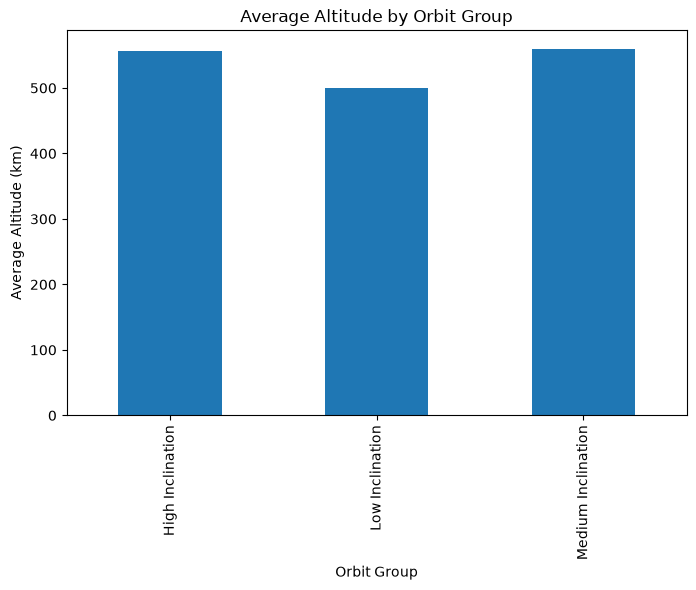

In [46]:
orbit_summary["Average_Altitude_km"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Orbit Group")
plt.ylabel("Average Altitude (km)")
plt.title("Average Altitude by Orbit Group")

plt.show()

In [47]:
print(clean_df["Altitude_km"].corr(
    clean_df["Inclination_deg"]
))

0.19554240390800756


## Day 5 — Deeper Analysis Result

### Orbit Group Analysis


We grouped satellites based on inclination:

- Low Inclination: below 60°
- Medium Inclination: 60° to below 85°
- High Inclination: 85° and above

### Findings

- The most common orbit group is: low inclination
- The average altitude of the Low Inclination group is: 0.000152 km
- The average altitude of the Medium Inclination group is: 0.000305 km
- The average altitude of the High Inclination group is: 557.149531 km
- The lowest altitude observed is: 172.457616  km
- The highest altitude observed is: 593.591274 km
- The altitude-inclination correlation is: 0.19554240390800756

### Observations

- Satellite altitudes are not uniformly distributed.
- The dataset contains distinct inclination groups.
- Some satellites have significantly lower altitudes than the majority.
- Different inclination groups show differences in their altitude distributions.








In [48]:
orbit_counts = clean_df["Orbit_Group"].value_counts()

orbit_counts

Orbit_Group
Low Inclination       6496
Medium Inclination     427
High Inclination       230
Name: count, dtype: int64

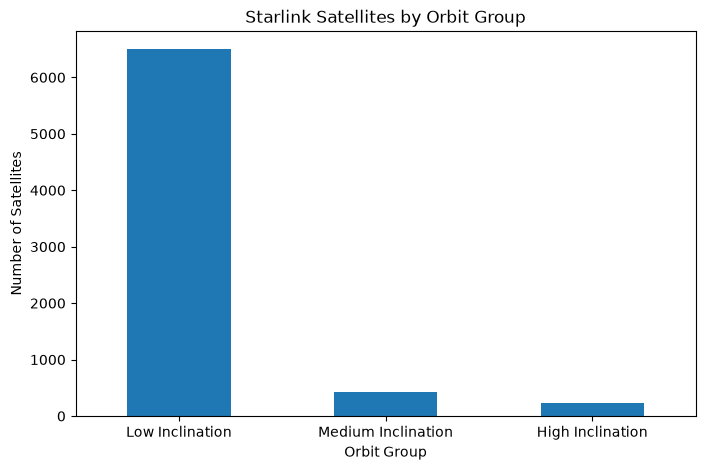

In [49]:
orbit_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Orbit Group")
plt.ylabel("Number of Satellites")
plt.title("Starlink Satellites by Orbit Group")

plt.xticks(rotation=0)

plt.show()

### Observation

The bar chart shows the distribution of Starlink satellites across the different inclination groups.

The largest group is **low inclination**.

The smallest group is **high inclination**.

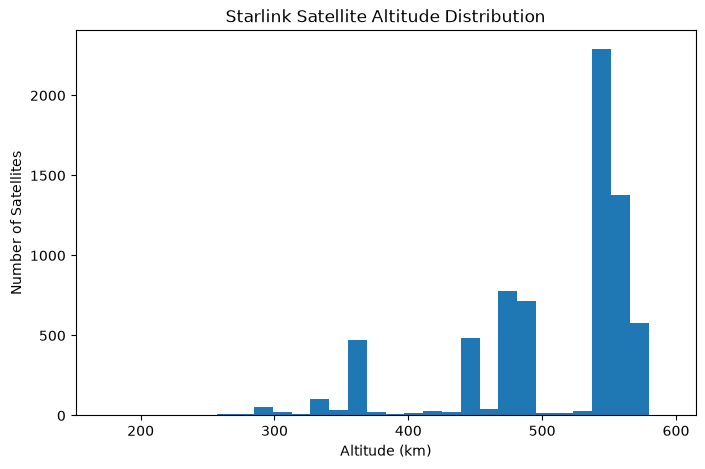

In [75]:
plt.figure(figsize=(8, 5))

plt.hist(
    clean_df["Altitude_km"],
    bins=30
)

plt.xlabel("Altitude (km)")
plt.ylabel("Number of Satellites")
plt.title("Starlink Satellite Altitude Distribution")


plt.savefig(
    "../visualizations/altitude_distribution.png",
    bbox_inches="tight"
)


plt.show()

### Observation

The altitude histogram shows that Starlink satellites are not evenly distributed across the altitude range.

Most satellites are concentrated around **500 - 600 km**.

A smaller number of satellites occur at much lower altitudes.

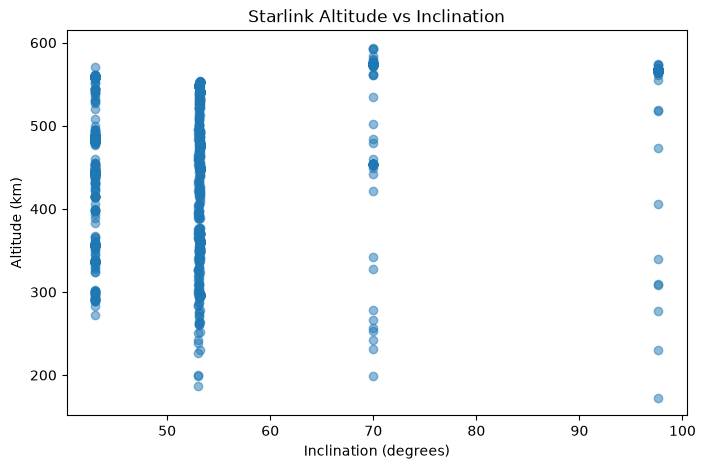

In [76]:
plt.figure(figsize=(8, 5))

plt.scatter(
    clean_df["Inclination_deg"],
    clean_df["Altitude_km"],
    alpha=0.5
)

plt.xlabel("Inclination (degrees)")
plt.ylabel("Altitude (km)")
plt.title("Starlink Altitude vs Inclination")


plt.savefig(
    "../visualizations/altitude_vs_inclination.png",
    bbox_inches="tight")

plt.show()

### Observation

The scatter plot shows clear clusters of satellites at different inclination values.

Major concentrations appear around approximately **53°, 70° and 98°**.

The altitude also varies across these groups, suggesting that different satellite orbit configurations are present in the dataset.

<Figure size 800x500 with 0 Axes>

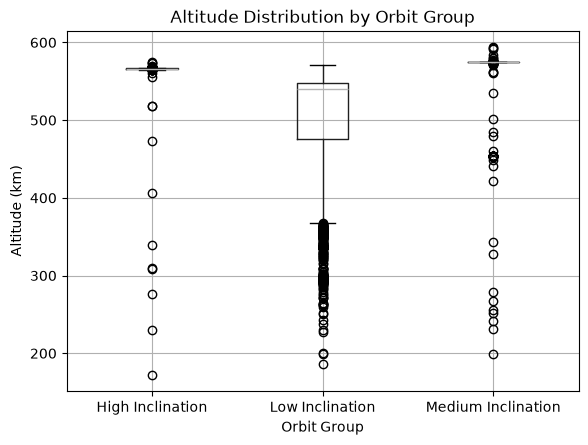

In [52]:
plt.figure(figsize=(8, 5))

clean_df.boxplot(
    column="Altitude_km",
    by="Orbit_Group"
)

plt.xlabel("Orbit Group")
plt.ylabel("Altitude (km)")
plt.title("Altitude Distribution by Orbit Group")

plt.suptitle("")

plt.show()

# Day 6 — Data Visualization Result

## Visualizations Created

### 1. Satellites by Orbit Group

Shows how the 7,153 satellites are distributed across the inclination groups.

### 2. Altitude Distribution

Shows how satellite altitudes are distributed across the dataset.

### 3. Altitude vs Inclination

Shows the relationship between satellite altitude and orbital inclination.

### 4. Altitude Distribution by Orbit Group

A box plot was used to compare altitude distributions between orbit groups.

## Key Observations

- Starlink satellites are distributed across several distinct inclination groups.
- Major inclination concentrations occur around approximately 53°, 70° and 98°.
- Satellite altitude is not uniformly distributed.
- Some satellites have substantially lower altitudes than the majority.
- The scatter plot shows visible clusters in the satellite data.

In [57]:
clean_df.shape

(7153, 9)

In [69]:
final_summary = pd.DataFrame({
    "Metric": [
        "Total Satellites",
        "Average Altitude (km)",
        "Minimum Altitude (km)",
        "Maximum Altitude (km)",
        "Average Inclination (°)",
        "Average Eccentricity"
    ],
    "Value": [
        clean_df["Satellite_Name"].count(),
        clean_df["Altitude_km"].mean(),
        clean_df["Altitude_km"].min(),
        clean_df["Altitude_km"].max(),
        clean_df["Inclination_deg"].mean(),
        clean_df["Eccentricity"].mean()
    ]
})

final_summary.round(2)

,Metric,Value
0,Total Satellites,7153.00
1,Average Altitude (km),505.83
2,Minimum Altitude (km),172.46
3,Maximum Altitude (km),593.59
4,Average Inclination (°),51.84
5,Average Eccentricity,0.00


In [70]:
final_summary.round(2).to_csv(
    "../data/processed/starlink_summary.csv",
    index=False
)

In [71]:
orbit_summary

,Satellite_Count,Average_Altitude_km,Minimum_Altitude_km,Maximum_Altitude_km
Orbit_Group,,,,
High Inclination,230,557.149531,172.457616,574.432970
Low Inclination,6496,500.457792,186.317039,570.936571
Medium Inclination,427,559.953043,198.611949,593.591274


In [72]:
orbit_summary.to_csv(
    "../data/processed/orbit_summary.csv"
)

# Day 7 — Project Organization

## Final Analysis Summary

The dataset contains 7,153 Starlink satellite records.

### Main Metrics

- Total satellites: 7,153
- Average altitude: approximately 506 km
- Minimum altitude: approximately 172 km
- Maximum altitude: approximately 594 km
- Average inclination: approximately 51.84°

### Project Outputs

- Cleaned Starlink dataset
- Summary statistics
- Orbit group analysis
- Altitude distribution chart
- Orbit group chart
- Altitude vs inclination scatter plot

### Project Status

Data collection, cleaning, exploratory analysis and visualization are complete.

The next stage is to convert these analysis results into a simple user-facing StarLinkScope application.